In [1]:
from desc import set_device
set_device("gpu")
import desc
from desc.equilibrium import Equilibrium

from desc.grid import LinearGrid
from desc.objectives import get_fixed_boundary_constraints
from desc.plotting import (
    plot_comparison,
    plot_fsa,
    plot_section,
    plot_surfaces,
    plot_qs_error,
    plot_1d,
    plot_2d,
)
import os
import aqsc
import numpy as np
import jax.numpy as jnp

In [2]:
from scipy.constants import mu_0

In [3]:
from qsc import Qsc
from matplotlib import pyplot as plt

In [4]:
eq = jnp.load('eq_fin.npy', allow_pickle=True).item()

In [5]:
eq.sigma0

Array(3.0580945e-12, dtype=float64)

In [6]:
B_denom0 = eq.B_denom[0]
B0 = np.sqrt(np.real(1/B_denom0))

# B = B_denom^-1/2
# B' = (-1/2)B_denom^-3/2 B_denom'
# B'' = (-1/2)(-3/2)B_denom^-5/2 (B_denom')^2 + (-1/2)B_denom^-3/2 B_denom''
#     =         3/4 B_denom^-5/2 (B_denom')^2 + (-1/2)B_denom^-3/2 B_denom''
# Substitute in eps = 0:
B1_eps = (-1/2) * B_denom0 ** (-3/2) * eq.B_denom.deps()[0]
B1_r = B1_eps * np.sqrt(B0 / 2)
B1s_r = np.real(B1_r.exp_to_trig().content[0, 0]) # Take the c1 component of B1 (not to be confused with B_denom[1])
B1c_r = np.real(B1_r.exp_to_trig().content[1, 0]) # Take the c1 component of B1 (not to be confused with B_denom[1])
B2_eps = (
    3/4 * B_denom0 ** (-5/2) * (eq.B_denom.deps() * eq.B_denom.deps())[0]
    -1/2 * B_denom0 ** (-3/2) * eq.B_denom.deps().deps()[0]
) / 2 # The factor of 2 comes from eps^2
B2_r = B2_eps * B0 / 2
# B20 is not a degree of freedom.
B2s_r = np.real(B2_r.exp_to_trig().content[0, 0])
B2c_r = np.real(B2_r.exp_to_trig().content[2, 0])


In [7]:
B2c_r

Array(0.92445762, dtype=float64)

In [8]:
qsc_eq = aqsc.aqsc_to_qsc(eq)
B_denom0 = eq.B_denom[0]
B0 = np.sqrt(np.real(1/B_denom0))

In [9]:
eps_crit, _, _ = np.sqrt(eq.get_psi_crit())
eps_conv = eq.get_eps_conv()
r_crit = qsc_eq.r_singularity
r_crit_equiv = eps_crit * np.sqrt(2/B0)
r_conv_equiv = eps_conv * np.sqrt(2/B0)

/tmp/ipykernel_1190918/2093387517.py:1: RuntimeWarning: invalid value encountered in sqrt
  eps_crit, _, _ = np.sqrt(eq.get_psi_crit())


In [10]:
print('AQSC eps crit', eps_crit)
print('AQSC eps conv', eps_conv)
print('QSC r crit                  ', r_crit)
print('QSC r crit (equiv from aqsc)', r_crit_equiv)

AQSC eps crit 0.035540587515570266
AQSC eps conv 0.052939400163154834
QSC r crit                   0.011364799316639581
QSC r crit (equiv from aqsc) 0.04643213301700915


In [11]:
# Saving
jnp.save('aux_data', {
    'eps_crit': eps_crit,
    'eps_conv': eps_conv,
    'r_crit': r_crit,
    'r_crit_equiv': r_crit_equiv,
    'r_conv_equiv': r_conv_equiv,
})

# DESC fit for both

In [12]:
# Here we fit both equilibrium to the same minor radius
if os.path.exists('desc_fit_aqsc_solved.h5'):
    desc_fit_aqsc = desc.io.load('desc_fit_aqsc.h5')
    desc_fit_aqsc_solved = desc.io.load('desc_fit_aqsc_solved.h5')
else:
    desc_fit_aqsc, desc_fit_aqsc_solved, aux_desc = aqsc.aqsc_to_desc_near_axis(
        eq, (r_crit / np.sqrt(2/B0))**2, n_max=6, 
        M=8, N=8, solve_force_balance=True,
        verbose=3
    )
    desc_fit_aqsc.save('desc_fit_aqsc.h5')
    desc_fit_aqsc_solved.save('desc_fit_aqsc_solved.h5')

Assuming stellarator symmetry.


2026-02-13 11:20:46.676819: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3023] Can't reduce memory use below 1.13GiB (1210423910 bytes) by rematerialization; only reduced to 2.26GiB (2428766208 bytes), down from 2.26GiB (2428766208 bytes) originally
/home/lf2869/Documents/Codes/DESC/desc/utils.py:572: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 724 ms
Timer: Objective build = 1.34 sec
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 504 ms
Timer: LinearConstraintProjection build = 4.81 sec
Number of parameters: 1069
Number of objectives: 8019
Timer: Initializing the optimization = 6.78 sec

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Ma

In [13]:
if os.path.exists('desc_fit_qsc_solved.h5'):
    desc_fit_qsc = desc.io.load('desc_fit_qsc.h5')
    desc_fit_qsc_solved = desc.io.load('desc_fit_qsc_solved.h5')
else:
    desc_fit_qsc = Equilibrium.from_near_axis(
        qsc_eq,  # the Qsc equilibrium object
        r=r_crit,  # the finite radius (m) at which to evaluate the Qsc surface to use as the DESC boundary
        L=8,  # DESC radial resolution
        M=8,  # DESC poloidal resolution
        N=8,  # DESC toroidal resolution
        ntheta=100,
    )
    desc_fit_qsc_solved = desc_fit_qsc.copy()
    constraints = get_fixed_boundary_constraints(eq=desc_fit_qsc_solved)
    # solve the equilibrium
    desc_fit_qsc_solved.solve(
        verbose=3,
        ftol=1e-2,
        objective="force",
        maxiter=100,
        xtol=1e-6,
        constraints=constraints,
    )
    desc_fit_qsc.save('desc_fit_qsc.h5')
    desc_fit_qsc_solved.save('desc_fit_qsc_solved.h5')


Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 673 ms
Timer: Objective build = 843 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 245 ms
Timer: LinearConstraintProjection build = 4.06 sec
Number of parameters: 1712
Number of objectives: 10098
Timer: Initializing the optimization = 5.35 sec

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum Allowed Total Δx Norm      : inf
Scaled Termination                 : True
Trust Region Method                : qr
Initial Trus

(<Figure size 576.162x384.108 with 4 Axes>,
 <Axes: title={'center': '$|\\mathbf{B}|~(T)$'}, xlabel='$\\zeta$', ylabel='$\\theta$'>)

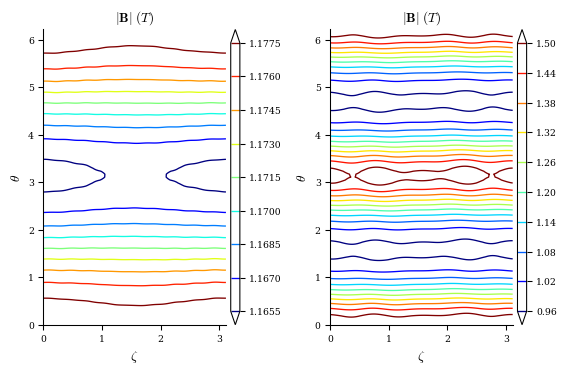

In [14]:
# Looks B2 is not correctly evaluated.
plotgridaxis = LinearGrid(
    M=50, N=50, NFP=desc_fit_aqsc.NFP, rho=np.array([0.5]), sym=False
)
fig, axs = plt.subplots(1, 2)
plot_2d(
    desc_fit_aqsc, 
    '|B|', grid=plotgridaxis, 
    filled=False, levels=10, ax=axs[0],
)
plot_2d(
    desc_fit_qsc, 
    '|B|', grid=plotgridaxis, 
    filled=False, levels=10, ax=axs[1],
)

(<Figure size 1200x500 with 3 Axes>,
 array([<Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.000$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.333$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.667$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>],
       dtype=object))

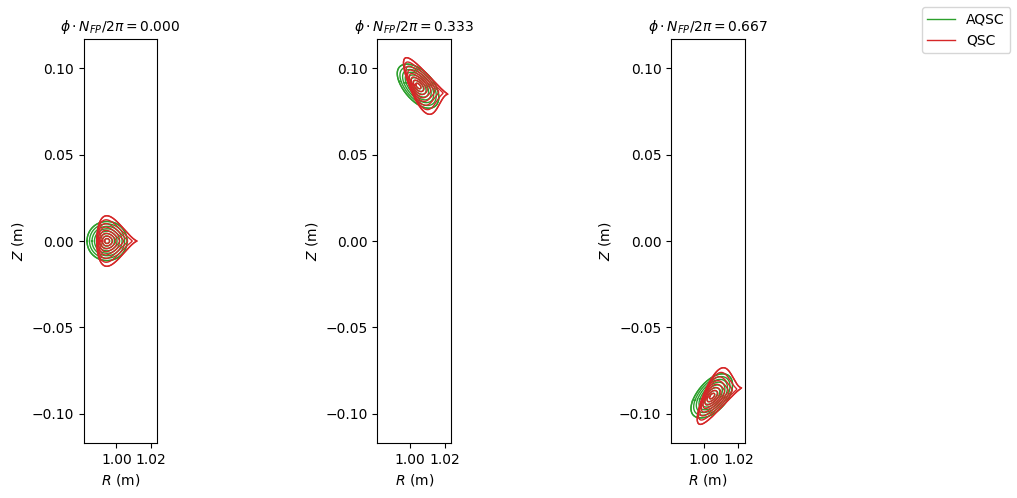

In [15]:
plt.style.use('default')
plt.rcParams["figure.constrained_layout.use"] = True
plot_comparison(
    [desc_fit_aqsc, desc_fit_qsc], 
    labels=['AQSC', 'QSC'],
    color=['tab:green', 'tab:red'],
    phi=3,
    theta=00,
    # rho=jnp.array([1e-2, 1.]),
)

(<Figure size 400x500 with 1 Axes>,
 array([<Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.000$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>],
       dtype=object))

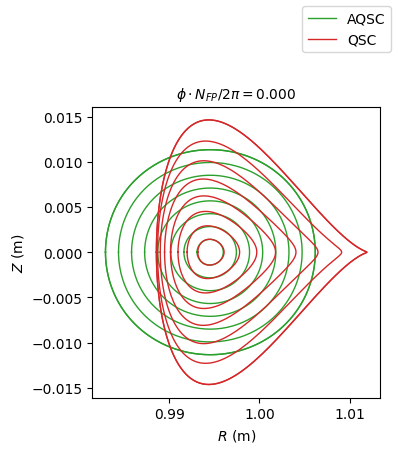

In [16]:
plt.style.use('default')
plt.rcParams["figure.constrained_layout.use"] = True
plot_comparison(
    [desc_fit_aqsc, desc_fit_qsc], 
    labels=['AQSC', 'QSC'],
    color=['tab:green', 'tab:red'],
    phi=1,
    theta=00,
    # rho=jnp.linspace(0, 0.5, 10),
)

In [17]:
def p_rr(eq):
    plotgridprof = LinearGrid(
        zeta=0, theta=0, NFP=desc_fit_aqsc.NFP, rho=np.linspace(0, 1, 100), sym=False
    )

    return eq.pressure.compute(dr=2, grid=plotgridprof)

In [18]:
p_rr(desc_fit_qsc).shape

(100,)

Text(0, 0.5, "p''")

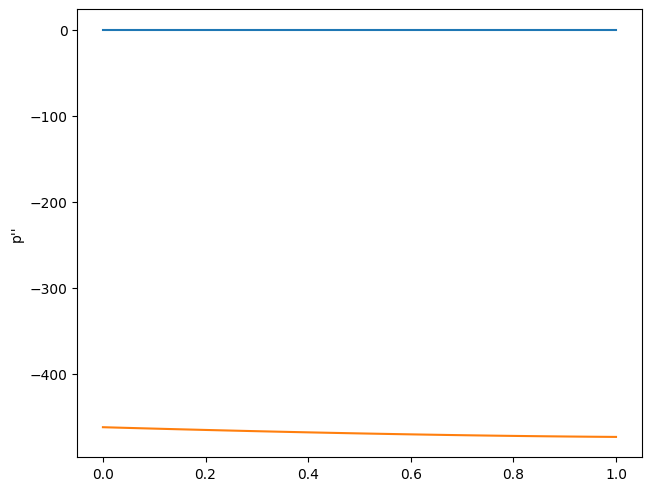

In [19]:
plt.plot(np.linspace(0, 1, 100), p_rr(desc_fit_qsc))
plt.plot(np.linspace(0, 1, 100), p_rr(desc_fit_aqsc))
plt.ylabel('p\'\'')

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$ \\iota ~(~)$'>)

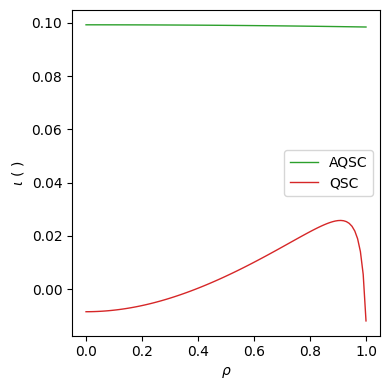

In [20]:

fig, ax = plot_1d(desc_fit_aqsc, 'iota', color='tab:green', label='AQSC')
plot_1d(desc_fit_qsc, 'iota', ax=ax, color='tab:red', label='QSC')

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$ p ~(Pa)$'>)

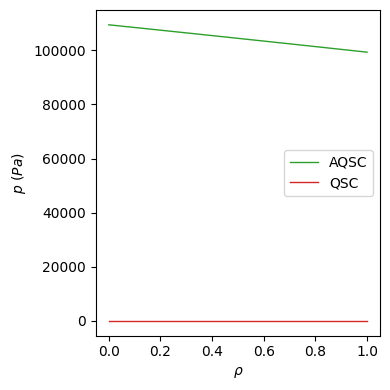

In [21]:
fig, ax = plot_1d(desc_fit_aqsc, 'pressure', color='tab:green', label='AQSC')
plot_1d(desc_fit_qsc, 'pressure', ax=ax, color='tab:red', label='QSC')

(<Figure size 600x600 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$|\\mathbf{B}|~(T)$'>)

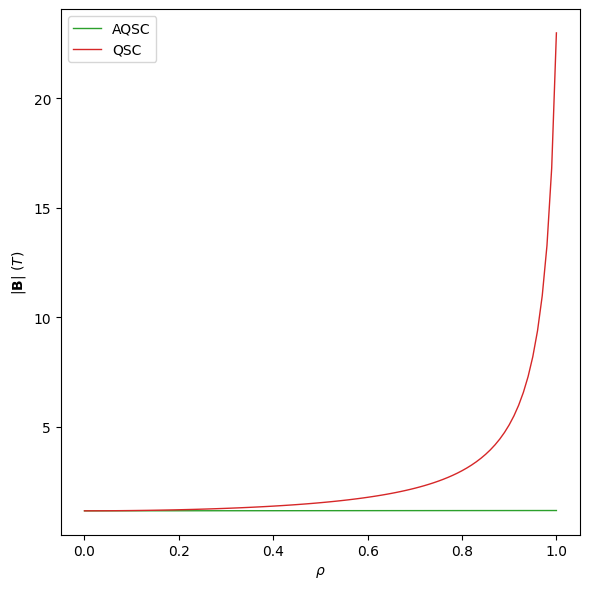

In [22]:
fig, ax = plot_1d(desc_fit_aqsc, '|B|', color='tab:green', label='AQSC')
plot_1d(desc_fit_qsc, '|B|', ax=ax, color='tab:red', label='QSC')

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$ I ~(T \\cdot m)$'>)

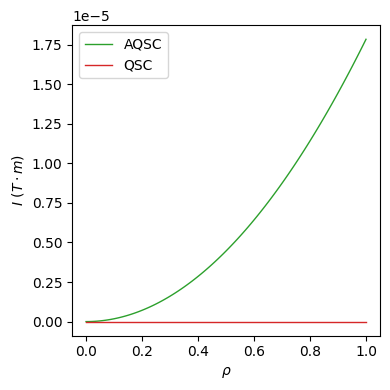

In [23]:

fig, ax = plot_1d(desc_fit_aqsc, 'I', color='tab:green', label='AQSC')
plot_1d(desc_fit_qsc, 'I', ax=ax, color='tab:red', label='QSC')

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$ G ~(T \\cdot m)$'>)

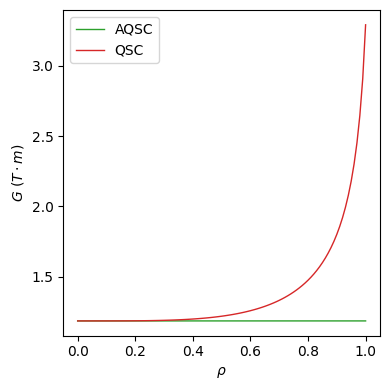

In [24]:

fig, ax = plot_1d(desc_fit_aqsc, 'G', color='tab:green', label='AQSC')
plot_1d(desc_fit_qsc, 'G', ax=ax, color='tab:red', label='QSC')

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$ \\partial_{\\rho} p ~(Pa)$'>)

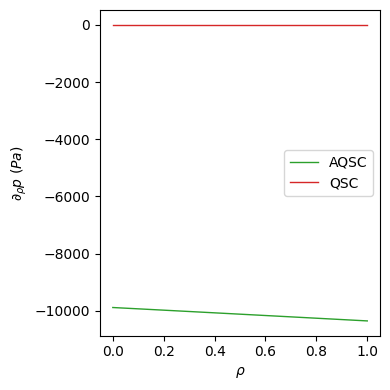

In [25]:

fig, ax = plot_1d(desc_fit_aqsc, 'p_r', color='tab:green', label='AQSC')
plot_1d(desc_fit_qsc, 'p_r', ax=ax, color='tab:red', label='QSC')

(<Figure size 1000x500 with 4 Axes>,
 <Axes: title={'center': '$|\\mathbf{B}|~(T)$'}, xlabel='$\\zeta$', ylabel='$\\theta$'>)

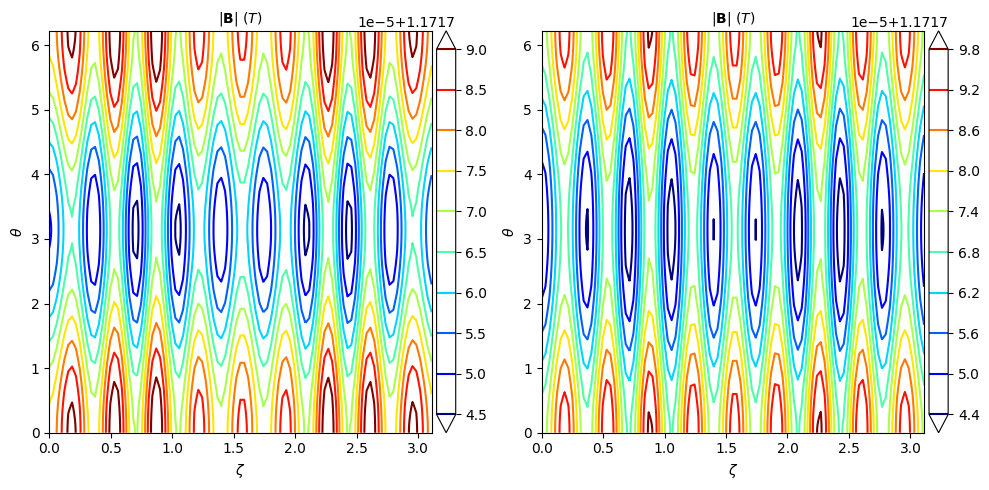

In [26]:
plotgridaxis = LinearGrid(
    M=50, N=50, NFP=desc_fit_aqsc.NFP, rho=np.array([0.001]), sym=False
)
fig, axs = plt.subplots(1,2, figsize=(10, 5))
plot_2d(desc_fit_aqsc, '|B|', grid=plotgridaxis, filled=False, levels=10, ax=axs[0]) #, ax=axs[0])
plot_2d(desc_fit_qsc, '|B|', grid=plotgridaxis, filled=False, levels=10, ax=axs[1]) #, ax=axs[1])

(<Figure size 1000x500 with 4 Axes>,
 <Axes: title={'center': '$|\\mathbf{B}|~(T)$'}, xlabel='$\\zeta$', ylabel='$\\theta$'>)

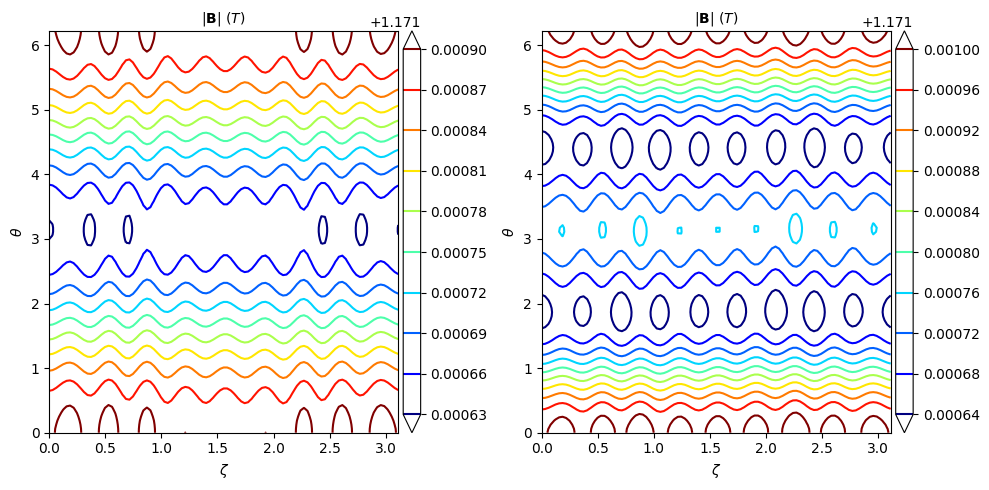

In [27]:
plotgridaxis = LinearGrid(
    M=50, N=50, NFP=desc_fit_aqsc.NFP, rho=np.array([0.01]), sym=False
)
fig, axs = plt.subplots(1,2, figsize=(10, 5))
plot_2d(desc_fit_aqsc, '|B|', grid=plotgridaxis, filled=False, levels=10, ax=axs[0]) #, ax=axs[0])
plot_2d(desc_fit_qsc, '|B|', grid=plotgridaxis, filled=False, levels=10, ax=axs[1]) #, ax=axs[1])

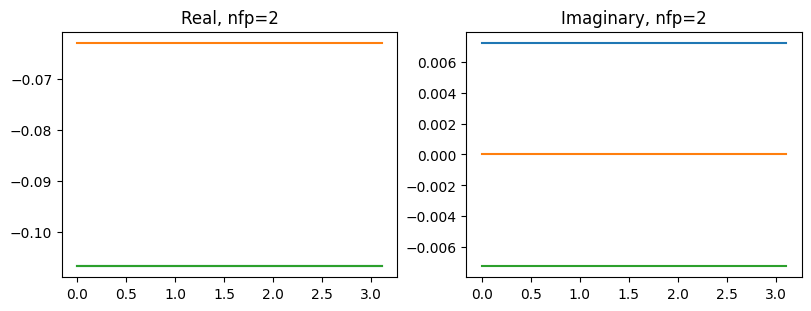

In [28]:
eq.B_denom[2].display_content()

(<Figure size 1000x500 with 4 Axes>,
 <Axes: title={'center': '$|\\mathbf{B}|~(T)$'}, xlabel='$\\zeta$', ylabel='$\\theta$'>)

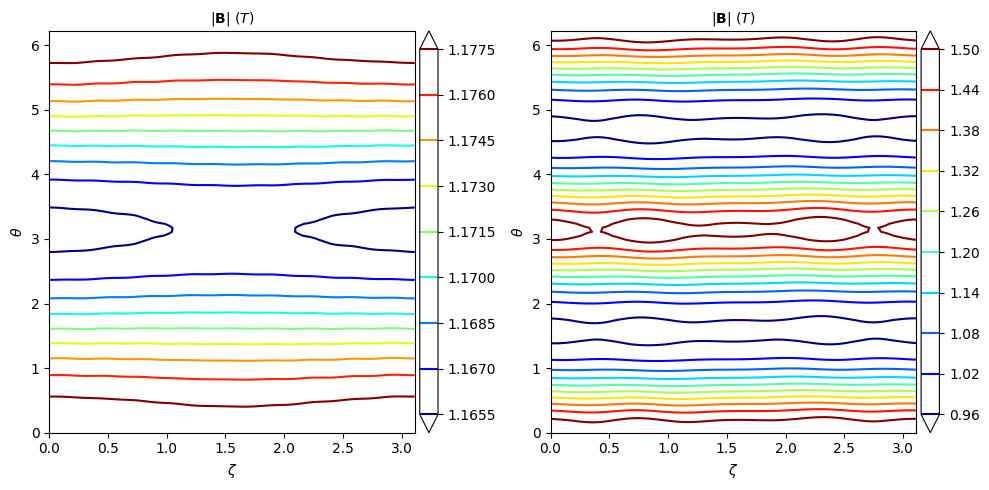

In [29]:
plotgridaxis = LinearGrid(
    M=50, N=50, NFP=desc_fit_aqsc.NFP, rho=np.array([0.5]), sym=False
)
fig, axs = plt.subplots(1,2, figsize=(10, 5))
plot_2d(desc_fit_aqsc, '|B|', grid=plotgridaxis, filled=False, levels=10, ax=axs[0]) #, ax=axs[0])
plot_2d(desc_fit_qsc, '|B|', grid=plotgridaxis, filled=False, levels=10, ax=axs[1]) #, ax=axs[1])

In [30]:
# B2s is the variation of B wrt "theta"
# "theta" is a boozer poloidal coordinate